### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


2. Load Dataset

In [ ]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

# Display basic info
print(df.head())
print(df.info())
print(df.describe())



   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               

### 3. Data Preprocessing

In [ ]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode categorical variables
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


### 4. Exploratory Data Analysis (EDA)

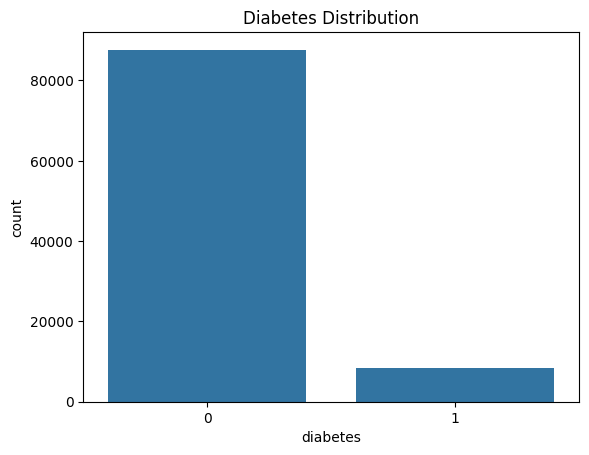

In [ ]:
# Distribution of target
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()


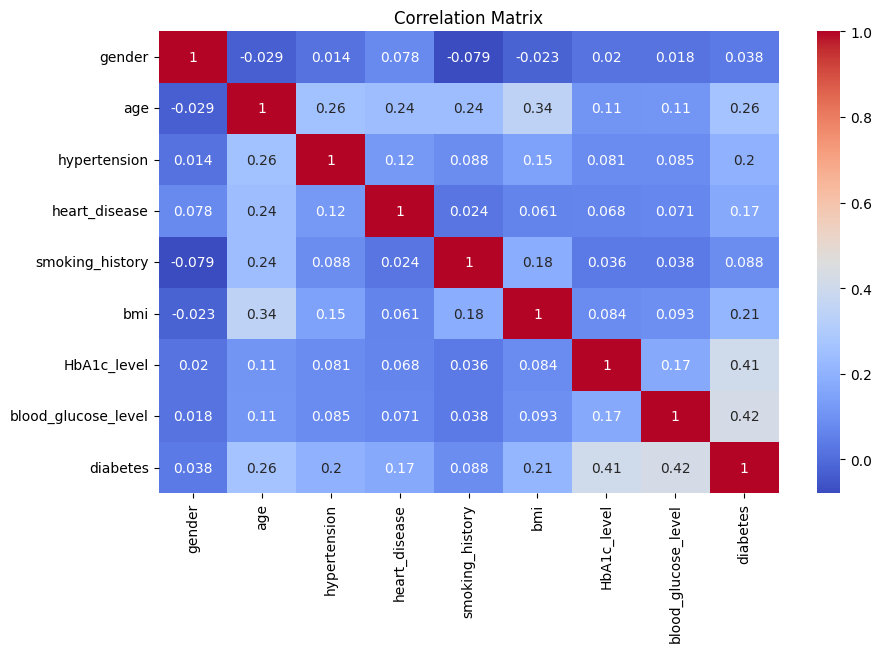

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


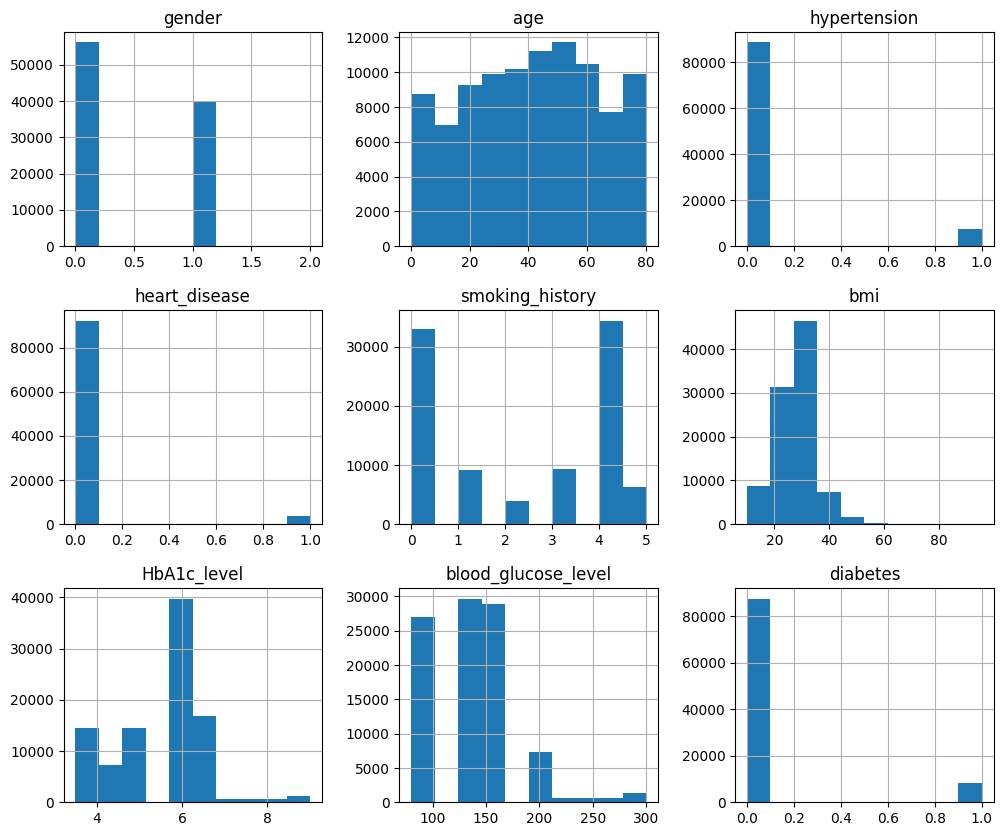

In [ ]:
# Feature distributions
df.hist(figsize=(12,10))
plt.show()


### 5. Feature Selection

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']


### 6. Data Normalization

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 7. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


8. Model Training

In [ ]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)


SVC()

9. Model Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


10. Evaluate All Models

In [ ]:
evaluate_model(lr, X_test, y_test, "Logistic Regression")
evaluate_model(dt, X_test, y_test, "Decision Tree")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test, y_test, "Support Vector Machine")



===== Logistic Regression =====
Accuracy: 0.9569422776911076
Precision: 0.8546465448768864
Recall: 0.6252178965717606
F1 Score: 0.7221476510067114

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230


===== Decision Tree =====
Accuracy: 0.9477379095163807
Precision: 0.6984478935698448
Recall: 0.7321324811156305
F1 Score: 0.7148936170212766

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     17509
           1       0.70      0.73      0.71      1721

    accuracy                           0.95     19230
   macro avg       0.84      0.85      0.84     19230
weighted avg       0.95      0.95      0.95     19230


=====

11. Comparison Table

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
accuracy = []
precision = []
recall = []
f1 = []

for model in [lr, dt, rf, svm]:
    y_pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

print("\nModel Comparison:\n")
print(results)



Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.956942   0.854647  0.625218  0.722148
1        Decision Tree  0.947738   0.698448  0.732132  0.714894
2        Random Forest  0.968175   0.939730  0.688553  0.794769
3                  SVM  0.961102   0.978368  0.578152  0.726808


Optional: Visual comparison

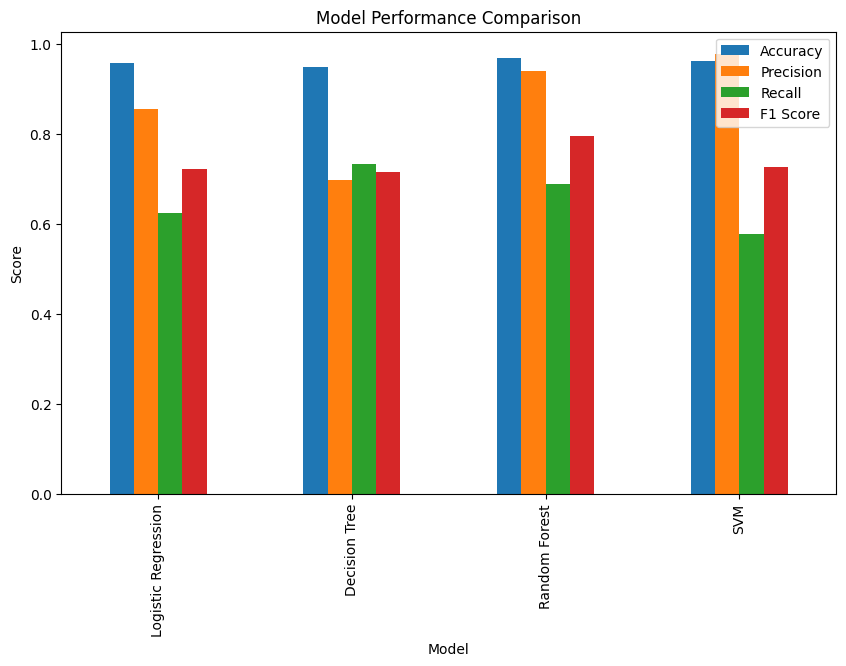

In [ ]:
results.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.show()